In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize

In [5]:
# --- 1. Data Exploration & Preprocessing ---
df = pd.read_csv('/content/glass.csv')

In [6]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64


In [7]:
# Summary Statistics
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.0

In [8]:
# Handle missing values in the target variable 'Type'
df.dropna(subset=['Type'], inplace=True)

In [9]:
# Standardizing numerical features
X = df.drop('Type', axis=1)
y = df['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

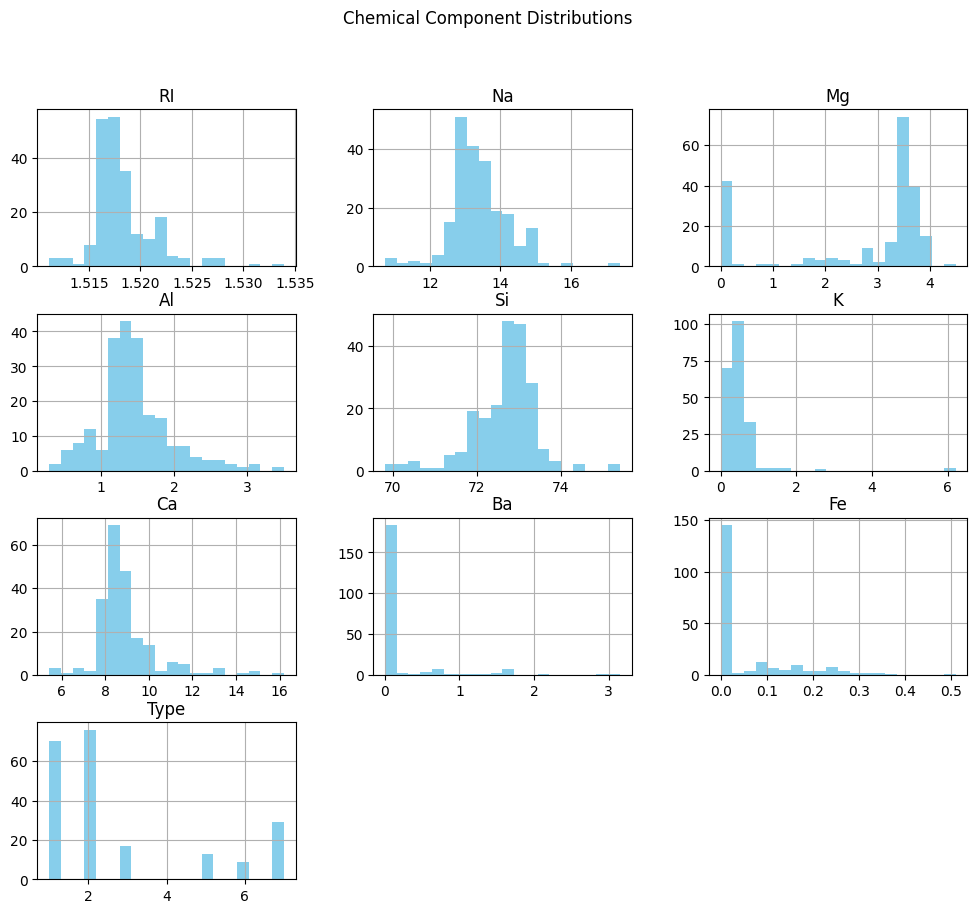

In [10]:
# Feature distributions
df.hist(figsize=(12, 10), bins=20, color='skyblue')
plt.suptitle("Chemical Component Distributions")
plt.show()

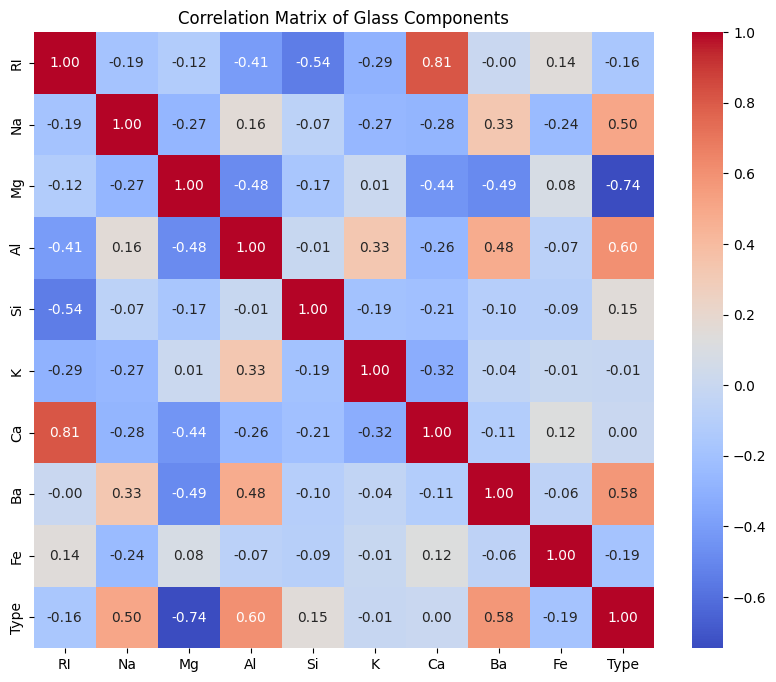

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Glass Components")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [13]:
# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'criterion': ['gini', 'entropy']
}


In [14]:
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("\nBest Parameters found:", rf_grid.best_params_)


Best Parameters found: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 50}


In [15]:
# --- 4. Evaluation and Analysis ---
y_pred = best_rf.predict(X_test)

In [16]:
# Metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.813953488372093

Classification Report:
               precision    recall  f1-score   support

         1.0       0.67      0.91      0.77        11
         2.0       0.82      0.64      0.72        14
         3.0       1.00      0.67      0.80         3
         5.0       1.00      0.75      0.86         4
         6.0       1.00      1.00      1.00         3
         7.0       0.89      1.00      0.94         8

    accuracy                           0.81        43
   macro avg       0.90      0.83      0.85        43
weighted avg       0.83      0.81      0.81        43



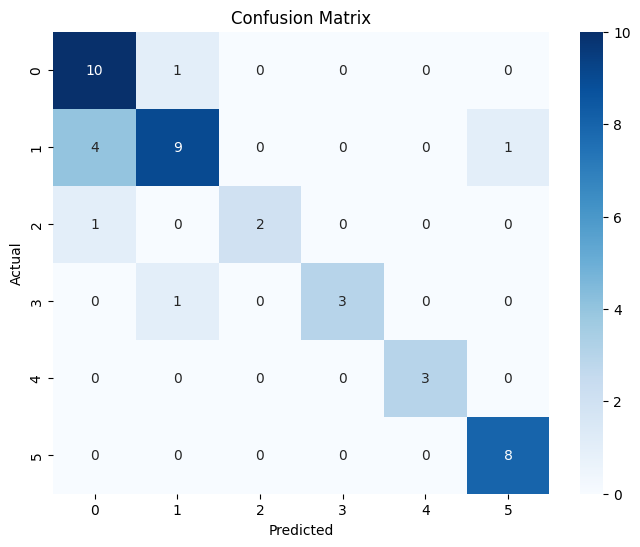

In [17]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

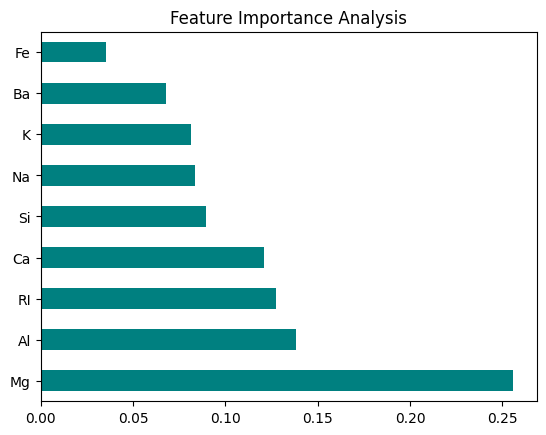

In [18]:
# Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Feature Importance Analysis")
plt.show()